In [6]:
# load free-bg GMM fits + matched-K SEAM k-means for the three validated peaks; per-peak arrays into a dict
import numpy as np, pandas as pd, h5py
import matplotlib.pyplot as plt

seam_dir = "/grid/koo/home/pmantill/projects/SEAM_validate/results/single_seq"
peaks = ["peak26256", "peak27535_Reversed", "peak84030"]   # the three free-bg fits in gmm_fits_freebg/
lib   = "100k"                                              # "100k" | "200k" | "300k"
K     = 100                                                 # GMM cluster count (== SEAM kmeans count)
suffix = {"100k": "", "200k": "_200k", "300k": "_300k"}[lib]
seam_cfg = f"foregrounds{suffix}_kmeans{K}"                 # matched-K SEAM run

fits = {}
for peak in peaks:
    g = np.load(f"{seam_dir}/gmm_fits_freebg/{peak}.{lib}.K{K}.seed0.npz")   # free-bg GMM fit
    mu_fg, Nk, gmm_labels = g["mu_fg"], g["Nk"], g["log_r"].argmax(1)        # fg deviations, soft occ, hard labels

    seam_pk = f"{seam_dir}/{seam_cfg}/{peak}"
    seam_fg = (np.load(f"{seam_pk}/cluster_maps.npy") - np.load(f"{seam_pk}/cluster_backgrounds.npy")).reshape(K, -1)
    seam_labels = np.load(f"{seam_pk}/cluster_labels.npy")
    seam_n = np.bincount(seam_labels, minlength=K)

    with h5py.File(f"{seam_dir}/ism{suffix}/{peak}.h5") as f:
        X = f["ism_centered"][:].reshape(-1, mu_fg.shape[1])      # (N, 800) the maps both methods clustered

    # empirical (normalized, signed) cluster means rebuilt from hard labels -- used by the coherence cells
    gmm_means = np.stack([X[gmm_labels == k].mean(0) if (gmm_labels == k).any()
                          else np.zeros(X.shape[1]) for k in range(K)])
    gmm_means /= np.linalg.norm(gmm_means, axis=1, keepdims=True) + 1e-12
    seam_means = np.stack([X[seam_labels == k].mean(0) for k in range(K)])
    seam_means /= np.linalg.norm(seam_means, axis=1, keepdims=True)

    fits[peak] = dict(mu_fg=mu_fg, Nk=Nk, gmm_labels=gmm_labels, gmm_means=gmm_means,
                      seam_fg=seam_fg, seam_n=seam_n, seam_labels=seam_labels, seam_means=seam_means, X=X)

print(f"loaded {len(fits)} peaks  |  lib {lib}  |  K={K}  |  free-bg GMM vs SEAM {seam_cfg}")

loaded 3 peaks  |  lib 100k  |  K=100  |  free-bg GMM vs SEAM foregrounds_kmeans100


In [7]:
# side-by-side summary stats per peak (no cluster matching)
rows = []
for peak, d in fits.items():
    gmm_norm, seam_norm = np.linalg.norm(d["mu_fg"], axis=1), np.linalg.norm(d["seam_fg"], axis=1)
    for name, occ, fgn in [("GMM", d["Nk"], gmm_norm), ("SEAM", d["seam_n"], seam_norm)]:
        nz = occ[occ >= 1]
        rows.append({"peak": peak, "set": name, "n_nonempty": int((occ >= 1).sum()),
                     "occ_min": int(nz.min()), "occ_med": int(np.median(nz)), "occ_max": int(occ.max()),
                     "fgnorm_mean": fgn.mean(), "fgnorm_med": np.median(fgn)})
summary = pd.DataFrame(rows).set_index(["peak", "set"]).round(3)
print(f"lib {lib}  |  K={K}  |  free-bg GMM vs SEAM {seam_cfg}")
summary

lib 100k  |  K=100  |  free-bg GMM vs SEAM foregrounds_kmeans100


n_nonempty  occ_min  occ_med  occ_max  fgnorm_mean  \
peak               set                                                        
peak26256          GMM          100        1     1073     2137        2.219   
                   SEAM         100      214      822     8540        1.804   
peak27535_Reversed GMM          100        1      969     2991        2.455   
                   SEAM         100      160      798    13484        1.918   
peak84030          GMM          100        1     1075     1797        2.289   
                   SEAM         100      154      877     7796        1.844   

                         fgnorm_med  
peak               set               
peak26256          GMM        2.328  
                   SEAM       1.694  
peak27535_Reversed GMM        2.560  
                   SEAM       1.783  
peak84030          GMM        2.237  
                   SEAM       1.538

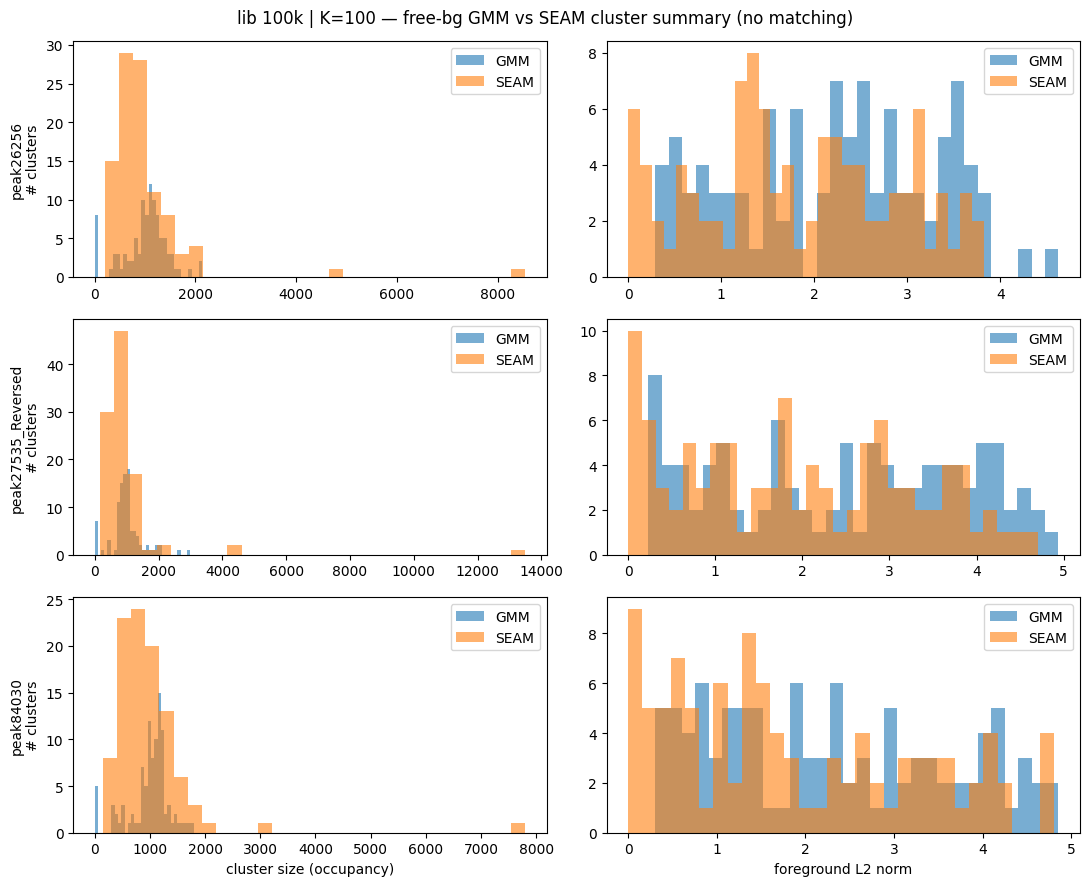

In [8]:
# compare the two clusterings' distributions per peak: cluster size and foreground strength (no matching)
fig, axes = plt.subplots(len(peaks), 2, figsize=(11, 3*len(peaks)))
for row, (peak, d) in zip(axes, fits.items()):
    row[0].hist(d["Nk"][d["Nk"] >= 1], bins=30, alpha=.6, label="GMM")
    row[0].hist(d["seam_n"][d["seam_n"] >= 1], bins=30, alpha=.6, label="SEAM")
    row[0].set_ylabel(f"{peak}\n# clusters"); row[0].legend()
    row[1].hist(np.linalg.norm(d["mu_fg"], axis=1), bins=30, alpha=.6, label="GMM")
    row[1].hist(np.linalg.norm(d["seam_fg"], axis=1), bins=30, alpha=.6, label="SEAM")
    row[1].legend()
axes[-1, 0].set_xlabel("cluster size (occupancy)"); axes[-1, 1].set_xlabel("foreground L2 norm")
fig.suptitle(f"lib {lib} | K={K} — free-bg GMM vs SEAM cluster summary (no matching)")
plt.tight_layout(); plt.show()

peak26256: within-cluster cosine  GMM 0.703  |  SEAM 0.743
peak27535_Reversed: within-cluster cosine  GMM 0.705  |  SEAM 0.756
peak84030: within-cluster cosine  GMM 0.745  |  SEAM 0.802


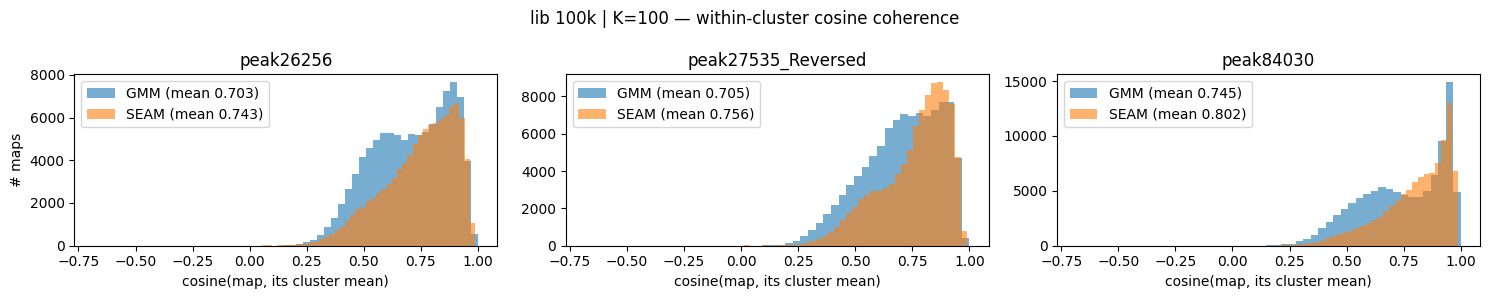

In [9]:
# within-cluster coherence: cosine of each attribution map to its own cluster's average logo (per peak)
fig, axes = plt.subplots(1, len(peaks), figsize=(5*len(peaks), 3), sharex=True)
for ax, (peak, d) in zip(axes, fits.items()):
    Xn = d["X"] / np.linalg.norm(d["X"], axis=1, keepdims=True)
    gmm_cos  = (Xn * d["gmm_means"][d["gmm_labels"]]).sum(1)      # GMM centroid = empirical mean of hard-assigned maps
    seam_cos = (Xn * d["seam_means"][d["seam_labels"]]).sum(1)    # SEAM centroid = empirical mean of k-means cluster
    ax.hist(gmm_cos,  bins=50, alpha=.6, label=f"GMM (mean {gmm_cos.mean():.3f})")
    ax.hist(seam_cos, bins=50, alpha=.6, label=f"SEAM (mean {seam_cos.mean():.3f})")
    ax.set_title(peak); ax.set_xlabel("cosine(map, its cluster mean)"); ax.legend()
    print(f"{peak}: within-cluster cosine  GMM {gmm_cos.mean():.3f}  |  SEAM {seam_cos.mean():.3f}")
axes[0].set_ylabel("# maps")
fig.suptitle(f"lib {lib} | K={K} — within-cluster cosine coherence"); plt.tight_layout(); plt.show()

peak26256: within-cluster per-position Pearson r  GMM 0.703  |  SEAM 0.747
peak27535_Reversed: within-cluster per-position Pearson r  GMM 0.657  |  SEAM 0.717
peak84030: within-cluster per-position Pearson r  GMM 0.734  |  SEAM 0.808


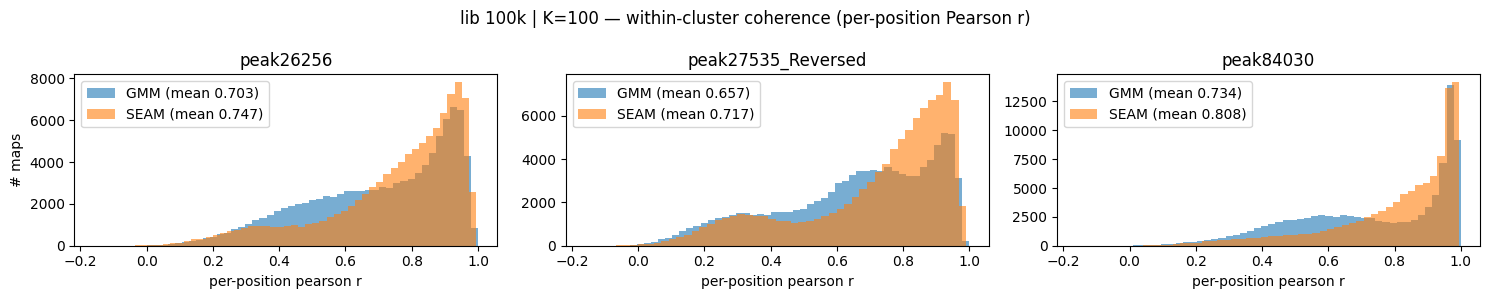

In [10]:
# per-position coherence: Pearson r between each map's positional importance profile and its cluster mean's
# (profile = per-position L2 magnitude over the 4 channels; correlation taken over the 200 positions)
def pos_profile(v):                                    # (M, 800) signed maps -> (M, 200) per-position magnitude
    return np.linalg.norm(v.reshape(v.shape[0], -1, 4), axis=2)

fig, axes = plt.subplots(1, len(peaks), figsize=(5*len(peaks), 3), sharex=True)
for ax, (peak, d) in zip(axes, fits.items()):
    P  = pos_profile(d["X"]);          P  -= P.mean(1, keepdims=True);  P  /= np.linalg.norm(P,  axis=1, keepdims=True)
    Cg = pos_profile(d["gmm_means"]);  Cg -= Cg.mean(1, keepdims=True); Cg /= np.linalg.norm(Cg, axis=1, keepdims=True)
    Cs = pos_profile(d["seam_means"]); Cs -= Cs.mean(1, keepdims=True); Cs /= np.linalg.norm(Cs, axis=1, keepdims=True)
    gmm_r  = (P * Cg[d["gmm_labels"]]).sum(1)
    seam_r = (P * Cs[d["seam_labels"]]).sum(1)
    ax.hist(gmm_r,  bins=50, alpha=.6, label=f"GMM (mean {gmm_r.mean():.3f})")
    ax.hist(seam_r, bins=50, alpha=.6, label=f"SEAM (mean {seam_r.mean():.3f})")
    ax.set_title(peak); ax.set_xlabel("per-position pearson r"); ax.legend()
    print(f"{peak}: within-cluster per-position Pearson r  GMM {gmm_r.mean():.3f}  |  SEAM {seam_r.mean():.3f}")
axes[0].set_ylabel("# maps")
fig.suptitle(f"lib {lib} | K={K} — within-cluster coherence (per-position Pearson r)"); plt.tight_layout(); plt.show()